# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip
from scipy.special import gamma
from scipy.optimize import minimize

data = np.genfromtxt('../../labs/02/data/claym2.csv', delimiter=',', names=True)
df = pd.DataFrame(data)
data = df

print(df.head())
print(df.shape)
#print((df["x"] == 0).sum())

           x
0  28.058137
1  26.576674
2  27.473474
3  24.851709
4  28.523620
(698, 1)


## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

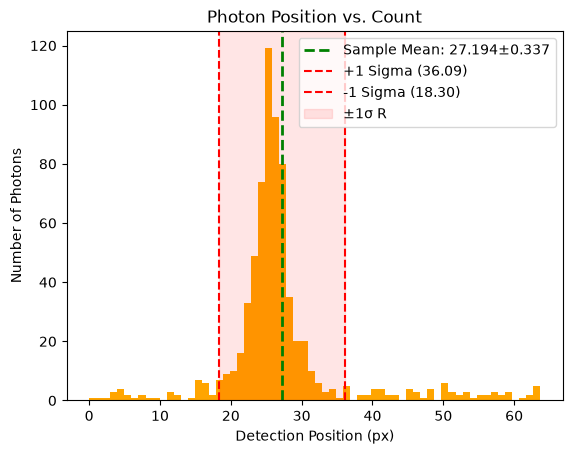

In [21]:
plt.hist(df,bins=64, color="orange")

sample_mean = df["x"].mean()
sm_uncertainty = (df["x"].std()/np.sqrt(len(df)))
plt.axvline(x=sample_mean, color="green", linestyle="--", linewidth=2,label=f"Sample Mean: {sample_mean:.3f}±{sm_uncertainty:.3f}")

#Around 50-100 bins gives you a nice looking distribution and trailing edges 
#Fewer than 50 bins only gives you a large peak, more than around 100/150 starts to spread your data around. 64 bins is one pixel across


mean = np.mean(data)
median = np.median(data)
sigma = np.std(data)
upper_limit = mean + (1 * sigma)
lower_limit = mean - (1 * sigma) #includes bg points, method below doesn't

plt.axvline(upper_limit,color="red",linestyle="--",label=f"+1 Sigma ({upper_limit:.2f})",)
plt.axvline(lower_limit,color="red",linestyle="--",label=f"-1 Sigma ({lower_limit:.2f})",)

plt.axvspan(lower_limit, upper_limit, color="red", alpha=0.1, label="±1σ R")

plt.xlabel("Detection Position (px)")
plt.ylabel("Number of Photons")
plt.title("Photon Position vs. Count")
plt.legend()
plt.show()

**ANSWER (a few sentences):**

The sample mean I calculated ended up being 27.194 ± 0.337. To me, it does not look like there is bias in the work above. I was working with selected, non-predicted values. The only thing I can think of that resulted in bias in this ending result would be the way the data was collected. Perhaps some of the "detections" are just unlucky instances which should have been nothing. Additoinally, some of the background in the data, or values above zero but not a clear detection, pull the averages slightly up. If I had to make a guess, I would say the sample mean is potentially just a little higher than what it is in reality.

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [22]:
# Median Estimator 

median = df["x"].median()
print(median)

25.811579000000002


Original photons: 698
Remaining photons: 561
Removed photons: 137
Clipped mean: 25.701380573975047
Clipped std: 2.242793513195429


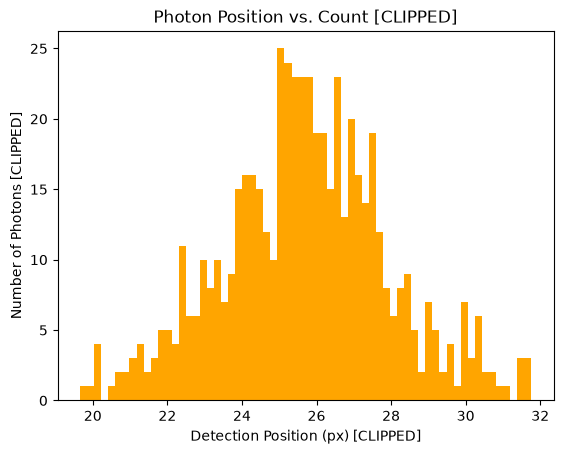

In [23]:
# Sigma-Clipping Mean Estimator

clipped = sigma_clip(data["x"], sigma=2.5)

#Keeping between 2.5 and 3 sigma seem to be the most ideal for this graph. I messed around with the boundaries, noticing
#that less than 2.5 started to clip into the distribution. Greater than three started to include parts of the tail end 
#that we are doing this process to remove. I settled on 2.5 as it includes the entire distribution as well as a little of the tail.
#3-sigma includes too much tail, and 2.5-sigma clips the distribution. 

clipped_data = data["x"][~clipped.mask]

print("Original photons:", len(data["x"]))
print("Remaining photons:", len(clipped_data))
print("Removed photons:", len(data["x"]) - len(clipped_data))

print("Clipped mean:", np.mean(clipped_data))
print("Clipped std:", np.std(clipped_data))

plt.hist(clipped_data,bins=64, color="orange")
plt.xlabel("Detection Position (px) [CLIPPED]")
plt.ylabel("Number of Photons [CLIPPED]")
plt.title("Photon Position vs. Count [CLIPPED]")
plt.show()

In [43]:
# Maximum Likelihood Mixture Model Method
beta = 2.5
r0 = 4
x = df["x"]

def probability(x, x0, f_bg):
    background = f_bg / 64
    normalization = (gamma(beta)/ (r0 * np.sqrt(np.pi) * gamma(beta - 0.5)))
    star = normalization * (1 + ((x - x0) / r0)**2)**(-beta)

    return background + (1 - f_bg) * star

def log_likelihood(theta, x):
    x0, f_bg = theta

    p = probability(x, x0, f_bg)

    return np.sum(np.log(p))

def negative_log_likelihood(theta, x):
    return -log_likelihood(theta, x)

theta0 = [26, 0.2]

from scipy.optimize import minimize

result = minimize(
    negative_log_likelihood, #which actually maximizes bc min -log = max
    theta0,
    args=(x,),
    method="Nelder-Mead"
)

x0_mle = result.x[0]
f_bg_mle = result.x[1]

print("x0 =", x0_mle)
print("f_bg =", f_bg_mle)

x0 = 25.678873011151147
f_bg = 0.19581343622696293


In [25]:
def numerical_hessian(func, theta, x, h=1e-4):
    n = len(theta)
    H = np.zeros((n, n))

    for i in range(n):
        for j in range(n):

            ei = np.zeros(n)
            ej = np.zeros(n)

            ei[i] = h
            ej[j] = h

            H[i, j] = (
                func(theta + ei + ej, x)
                - func(theta + ei - ej, x)
                - func(theta - ei + ej, x)
                + func(theta - ei - ej, x)
            ) / (4 * h**2)

    return H


H = numerical_hessian(
    negative_log_likelihood,
    result.x,
    x
)

print(H)

covariance = np.linalg.inv(H)

sigma_x0 = np.sqrt(covariance[0, 0])
sigma_fbg = np.sqrt(covariance[1, 1])
print(f"x0 = {x0_mle:.3f} ± {sigma_x0:.3f} px")
print(f"f_bg = {f_bg_mle:.3f} ± {sigma_fbg:.3f}")
print(result.success)
print(result.message)

[[  92.58034197   -4.06541858]
 [  -4.06541858 2984.86704651]]
x0 = 25.679 ± 0.104 px
f_bg = 0.196 ± 0.018
True
Optimization terminated successfully.


In [26]:
for guess in [[24, 0.1], [26, 0.2], [28, 0.4]]:
    result_test = minimize(
        negative_log_likelihood,
        guess,
        args=(x,),
        method="Nelder-Mead"
    )

    print(result_test.x)

[25.67886161  0.19582861]
[25.67887301  0.19581344]
[25.67894808  0.19583244]


In [27]:
# Cramér–Rao Bound

# Our parameter estimates from the MLE
theta = np.array([x0_mle, f_bg_mle])

# Detector window: 0 to 64 pixels
# 10,000 points gives a fine numerical grid for the integral
x_grid = np.linspace(0, 64, 10000)


# Model probability density
def model(x, theta):
    x0, f_bg = theta
    return probability(x, x0, f_bg)


# Numerical Jacobian
# Central difference approximation to the derivatives
h = 1e-5

J = np.array([
    (model(x_grid, theta + h*np.array([1, 0])) -
     model(x_grid, theta - h*np.array([1, 0]))) / (2*h),

    (model(x_grid, theta + h*np.array([0, 1])) -
     model(x_grid, theta - h*np.array([0, 1]))) / (2*h)
]).T


# Probability density evaluated at our estimated parameters
p = model(x_grid, theta)


# Per-photon Fisher information matrix
F = np.zeros((2, 2))

for i in range(2):
    for j in range(2):
        integrand = J[:, i] * J[:, j] / p
        F[i, j] = np.trapezoid(integrand, x_grid)


# Total Fisher information from all photons
N = len(x)
F_total = N * F


# Cramér–Rao covariance matrix
C_crb = np.linalg.inv(F_total)


# CRB uncertainties
sigma_x0_crb = np.sqrt(C_crb[0, 0])
sigma_fbg_crb = np.sqrt(C_crb[1, 1])

print("Per-photon Fisher matrix:")
print(F)

print("\nTotal Fisher matrix:")
print(F_total)

print("\nCRB covariance matrix:")
print(C_crb)

print("\nCRB sigma_x0 =", sigma_x0_crb)
print("CRB sigma_fbg =", sigma_fbg_crb)


#I was able to cross-validate many of Chat's errors by providing in-depth prompts to ask it to explain very choice it made.
#Additionally, once I gave it my prompts and notebooks + notes, it was able to accurately revise its initial solutions 
#To more closely match the class work. I even got it to correct two or three assumptions based on that.

Per-photon Fisher matrix:
[[1.30987676e-01 5.70541232e-05]
 [5.70541232e-05 4.32367512e+00]]

Total Fisher matrix:
[[9.14293977e+01 3.98237780e-02]
 [3.98237780e-02 3.01792523e+03]]

CRB covariance matrix:
[[ 1.09374012e-02 -1.44327180e-07]
 [-1.44327180e-07  3.31353473e-04]]

CRB sigma_x0 = 0.1045820310621664
CRB sigma_fbg = 0.018203117117658672


**FINAL ANSWER:** $x_0 = $ ___ $\pm$ ___ px , $f_{\rm bg} = $ ___ $\pm$ ___ , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ ___ px

**Justification and uncertainty method (a short paragraph):**

x0 = 25.679 ± 0.104 px and f_bg = 0.196 ± 0.018, CRB for x0: 0.1045820310621664 px


I estimated $x_0$ and $f_{\rm bg}$ using maximum likelihood under the specified two-component mixture model, in which each photon has a probability of originating either from the uniform background or from the Moffat star profile. I maximized the summed log-likelihood over both parameters using numerical optimization. I estimated the parameter uncertainties from the curvature of the negative log-likelihood at its optimum, i.e. the inverse observed-information/Hessian matrix. This method uses all photons rather than explicitly rejecting background detections, allowing the background fraction to be estimated simultaneously with the stellar position.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

I will use the x0 center as 30 px and the fbg as 20, same above as my guess. I will use the given 2.5 and 4 for beta and r0 respectively. I can look into using the Student-t fact from above to get this done.

I will use the same estimators from above: the mean, median, sigma, and MLE.

If everything works well, the x0 and fbg should be reasonably close to the known values. 

If things go wrong, the results will not look similar to the known values. 

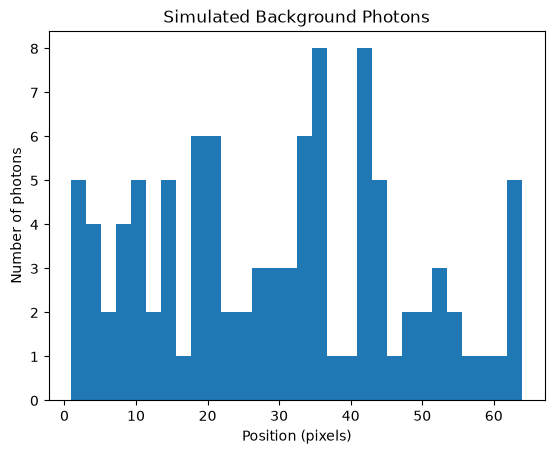

In [28]:
# Part 3b: execute the plan here

true_x0 = 30.0
true_fbg = 0.20
beta = 2.5
r0 = 4.0
window = 64.0
N = 698

rng = np.random.default_rng(20260916)

def generate_star_photons(n, x0, beta, r0, rng):
    """
    Generate n stellar photon positions.

    Photons outside the detector window are rejected
    and regenerated.
    """

    degrees_of_freedom = 2 * beta - 1
    scale = r0 / np.sqrt(degrees_of_freedom)

    photons = []

    while len(photons) < n:

        # Generate Student-t random values
        candidates = (
            x0
            + scale * rng.standard_t(degrees_of_freedom, size=n)
        )

        # Keep only photons inside the detector
        valid = candidates[
            (candidates >= 0)
            & (candidates <= 64)
        ]

        photons.extend(valid)

    return np.array(photons[:n])
    
def generate_background_photons(n, rng):
    return rng.uniform(0, 64, size=n)

background_photons = generate_background_photons(100, rng)

plt.hist(background_photons, bins=30)
plt.xlabel("Position (pixels)")
plt.ylabel("Number of photons")
plt.title("Simulated Background Photons")
plt.show()

Number of photons: 698
Mean: 29.561501159833057
Median: 29.84695765381357


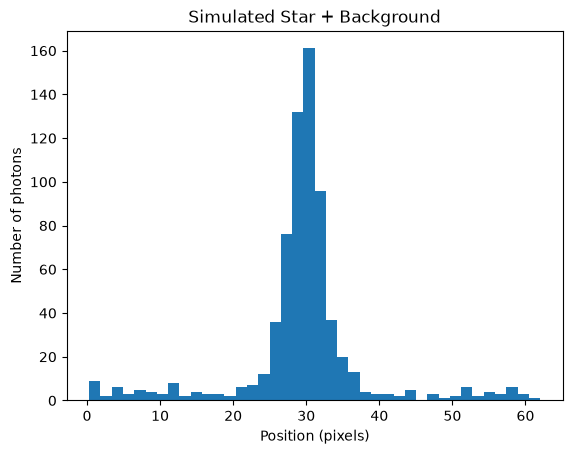

In [29]:
def simulate_dataset(N, x0, fbg, beta, r0, rng):

    # Decide which photons are background
    is_background = rng.random(N) < fbg

    n_background = np.sum(is_background)
    n_star = N - n_background

    # Generate each component
    background = generate_background_photons(
        n_background,
        rng
    )

    star = generate_star_photons(
        n_star,
        x0,
        beta,
        r0,
        rng
    )

    # Combine the photons
    photons = np.empty(N)

    photons[is_background] = background
    photons[~is_background] = star

    # Shuffle so the two populations are mixed
    rng.shuffle(photons)

    return photons

simulated_x = simulate_dataset(
    N=N,
    x0=true_x0,
    fbg=true_fbg,
    beta=beta,
    r0=r0,
    rng=rng
)

print("Number of photons:", len(simulated_x))
print("Mean:", np.mean(simulated_x))
print("Median:", np.median(simulated_x))

plt.hist(simulated_x, bins=40)

plt.xlabel("Position (pixels)")
plt.ylabel("Number of photons")
plt.title("Simulated Star + Background")

plt.show()

Value finding time:

In [30]:
mean_estimate = np.mean(simulated_x)
mean_uncertainty = (
    np.std(simulated_x, ddof=1)
    / np.sqrt(len(simulated_x))
)

print("Mean:", mean_estimate)
print("Mean uncertainty:", mean_uncertainty)

median_estimate = np.median(simulated_x)

print("Median:", median_estimate)

Mean: 29.561501159833057
Mean uncertainty: 0.32466570059720407
Median: 29.84695765381357


In [31]:
def sigma_clipped_mean(x, sigma_threshold=2.5):

    mask = np.ones(len(x), dtype=bool)

    for iteration in range(100):

        center = np.mean(x[mask])
        std = np.std(x[mask], ddof=1)

        new_mask = np.abs(x - center) < sigma_threshold * std

        # Stop if no more points are removed
        if np.array_equal(new_mask, mask):
            break

        mask = new_mask

    clipped_x = x[mask]

    estimate = np.mean(clipped_x)

    return estimate, clipped_x, iteration + 1

clipped_estimate, clipped_data, iterations = (
    sigma_clipped_mean(simulated_x)
)

print("Clipped mean:", clipped_estimate)
print("Remaining photons:", len(clipped_data))
print("Removed photons:", len(simulated_x) - len(clipped_data))
print("Iterations:", iterations)

Clipped mean: 29.833608744730284
Remaining photons: 567
Removed photons: 131
Iterations: 7


MLE Part

In [45]:


def star_probability(x, x0, beta=2.5, r0=4.0):

    normalization = (
        gamma(beta)
        / (
            r0
            * np.sqrt(np.pi)
            * gamma(beta - 0.5)
        )
    )

    return normalization * (
        1 + ((x - x0) / r0) ** 2
    ) ** (-beta)

def probability(x, x0, fbg):

    background = fbg / 64

    star = (
        (1 - fbg)
        * star_probability(x, x0)
    )

    return background + star

def negative_log_likelihood(theta, x):

    x0, fbg = theta

    p = probability(x, x0, fbg)

    # Prevent log(0)
    if np.any(p <= 0):
        return np.inf

    return -np.sum(np.log(p))

initial_guess = [26, 0.2]

result = minimize(
    negative_log_likelihood,
    initial_guess,
    args=(simulated_x,),
    method="L-BFGS-B",
    bounds=[
        (0, 64),  # x0 must be inside detector
        (0, 1)    # fbg must be between 0 and 1
    ]
)

mle_x0 = result.x[0]
mle_fbg = result.x[1]

print("MLE x0:", mle_x0)
print("MLE fbg:", mle_fbg)
print("Success:", result.success)

print("True x0:", true_x0)
print()

print("Mean estimate:", mean_estimate)
print("Median estimate:", median_estimate)
print("Clipped mean:", clipped_estimate)
print("MLE estimate:", mle_x0)

MLE x0: 29.889823647615756
MLE fbg: 0.18945053729882963
Success: True
True x0: 30.0

Mean estimate: 29.561501159833057
Median estimate: 29.84695765381357
Clipped mean: 29.97356124535831
MLE estimate: 29.889823647615756


Monte Carlo time. Everything above this line now done 300 times and plotted.

In [44]:
n_simulations = 300

# Store results
mean_results = []
median_results = []
clipped_results = []
mle_x0_results = []
mle_fbg_results = []

for i in range(n_simulations):
    simulated_data = simulate_dataset(
        N=N,
        x0=true_x0,
        fbg=true_fbg,
        beta=beta,
        r0=r0,
        rng=rng
    )

    # Three estimators that estimate x0 only
    mean_results.append(np.mean(simulated_data))
    median_results.append(np.median(simulated_data))

    clipped_estimate, _, _ = sigma_clipped_mean(simulated_data)
    clipped_results.append(clipped_estimate)

    # MLE estimates both x0 and fbg
    mle_result = minimize(
        negative_log_likelihood,
        x0=[true_x0, true_fbg],
        args=(simulated_data,),
        bounds=[(0, window), (0, 1)],
        method="L-BFGS-B"
    )

    if mle_result.success:
        mle_x0_results.append(mle_result.x[0])
        mle_fbg_results.append(mle_result.x[1])

# Convert lists to arrays
mean_results = np.array(mean_results)
median_results = np.array(median_results)
clipped_results = np.array(clipped_results)
mle_x0_results = np.array(mle_x0_results)
mle_fbg_results = np.array(mle_fbg_results)

# Compare x0 estimators
estimators = {
    "Mean": mean_results,
    "Median": median_results,
    "Clipped mean": clipped_results,
    "MLE": mle_x0_results,
}

for name, values in estimators.items():
    bias = np.mean(values) - true_x0
    variance = np.var(values, ddof=1)
    standard_deviation = np.std(values, ddof=1)

    print(name)
    print(f"  Bias: {bias:.4f}")
    print(f"  Variance: {variance:.4f}")
    print(f"  Standard deviation: {standard_deviation:.4f}")
    print()

print(f"Successful MLE fits: {len(mle_x0_results)} / {n_simulations}")


Mean
  Bias: 0.3874
  Variance: 0.1055
  Standard deviation: 0.3248

Median
  Bias: 0.0304
  Variance: 0.0168
  Standard deviation: 0.1296

Clipped mean
  Bias: -0.0119
  Variance: 0.0136
  Standard deviation: 0.1165

MLE
  Bias: -0.0133
  Variance: 0.0118
  Standard deviation: 0.1086

Successful MLE fits: 300 / 300


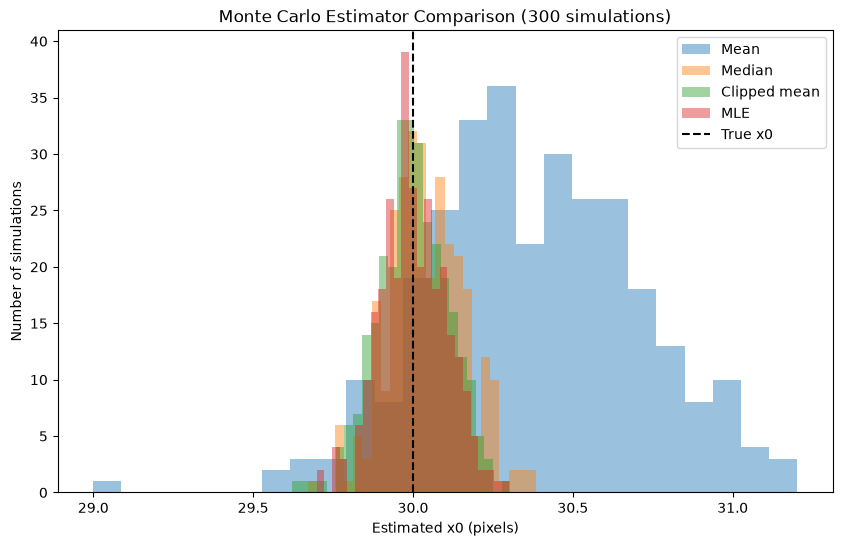

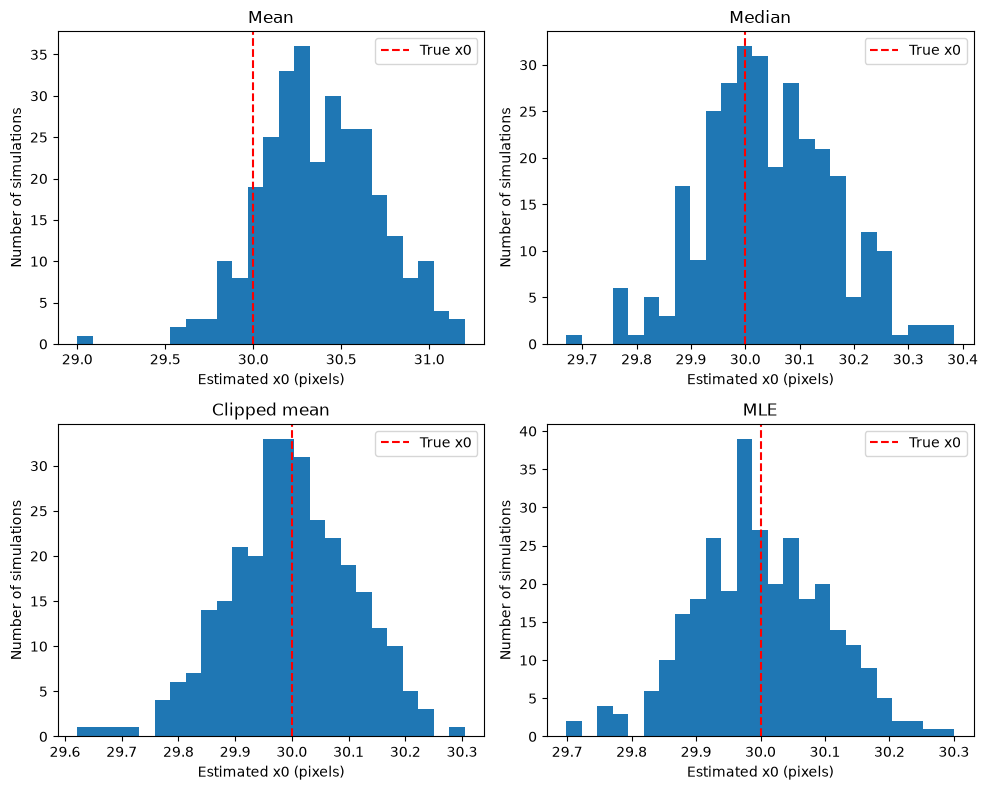

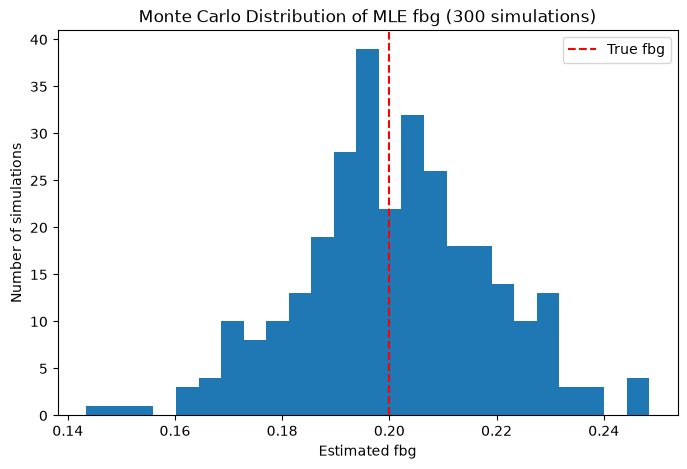

In [35]:
# Compare the sampling distributions of the x0 estimators

plt.figure(figsize=(10, 6))

plt.hist(mean_results, bins=25, alpha=0.45, label="Mean")
plt.hist(median_results, bins=25, alpha=0.45, label="Median")
plt.hist(clipped_results, bins=25, alpha=0.45, label="Clipped mean")
plt.hist(mle_x0_results, bins=25, alpha=0.45, label="MLE")

plt.axvline(true_x0, linestyle="--", color="black", label="True x0")
plt.xlabel("Estimated x0 (pixels)")
plt.ylabel("Number of simulations")
plt.legend()
plt.title(f"Monte Carlo Estimator Comparison ({n_simulations} simulations)")
plt.show()

# Separate plots are easier to read than overlapping histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, values) in zip(axes.flat, estimators.items()):
    ax.hist(values, bins=25)
    ax.axvline(true_x0, linestyle="--", color="red", label="True x0")
    ax.set_title(name)
    ax.set_xlabel("Estimated x0 (pixels)")
    ax.set_ylabel("Number of simulations")
    ax.legend()

plt.tight_layout()
plt.show()

# The MLE also estimates fbg, so check its sampling distribution separately
plt.figure(figsize=(8, 5))
plt.hist(mle_fbg_results, bins=25)
plt.axvline(true_fbg, linestyle="--", color="red", label="True fbg")
plt.xlabel("Estimated fbg")
plt.ylabel("Number of simulations")
plt.title(f"Monte Carlo Distribution of MLE fbg ({n_simulations} simulations)")
plt.legend()
plt.show()


**WHAT THE CHECKS FOUND:**

The Monte Carlo Estimators show that over 300 estimations, the median, clipped mean, and mle have nice distributions right around our known x0 of 30. Additionally, mean estimations converge near a point as well. We utilized known data to generate a sample dataset with a sample background (shown above). I implemented the same methods from the dataset on these generated data, leading to consistent results that matched the known parameters. Similarly, f_bg was preducted very strongly as well, as seen in the last graph.

In [36]:
# ==========================================
# Compare Monte Carlo MLE results to known true values
# ==========================================

average_x0 = np.mean(mle_x0_results)
average_fbg = np.mean(mle_fbg_results)

x0_bias = average_x0 - true_x0
fbg_bias = average_fbg - true_fbg

print("MLE comparison to known true values\n")

print(f"True x0:       {true_x0:.3f}")
print(f"Average x0:    {average_x0:.3f}")
print(f"x0 bias:       {x0_bias:+.3f}\n")

print(f"True f_bg:     {true_fbg:.3f}")
print(f"Average f_bg:  {average_fbg:.3f}")
print(f"f_bg bias:     {fbg_bias:+.3f}")

MLE comparison to known true values

True x0:       30.000
Average x0:    30.000
x0 bias:       +0.000

True f_bg:     0.200
Average f_bg:  0.201
f_bg bias:     +0.001


**Failure criteria stated in advance:**
- Large bias compared with the sampling standard deviation would suggest an estimator is systematically offset.
- A very broad or strongly skewed sampling distribution would indicate substantial estimator variability.
- Strong correlation between fitted $x_0$ and $f_{\rm bg}$ would show that the two parameters are not estimated independently.
- A Monte Carlo variance substantially below the CRB would be a warning sign, because it may indicate an implementation or comparison error.
- Large changes in the Hessian uncertainty when the step size changes would indicate numerical instability.

In [37]:
# Additional check 1: compact summary of bias and sampling spread
# This makes it easier to compare the estimators on the same scale.

summary_rows = []
for name, values in estimators.items():
    summary_rows.append({
        "Estimator": name,
        "Mean estimate": np.mean(values),
        "Bias": np.mean(values) - true_x0,
        "Standard deviation": np.std(values, ddof=1),
        "RMSE": np.sqrt(np.mean((values - true_x0) ** 2))
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Estimator,Mean estimate,Bias,Standard deviation,RMSE
0,Mean,30.379185,0.379185,0.332460,0.503927
1,Median,30.043487,0.043487,0.119382,0.126869
2,Clipped mean,29.999124,-0.000876,0.109437,0.109258
3,MLE,30.000167,0.000167,0.101754,0.101585


In [38]:
# Central 68% empirical interval for each x0 estimator

interval_rows = []
for name, values in estimators.items():
    lower, upper = np.percentile(values, [16, 84])
    interval_rows.append({
        "Estimator": name,
        "16th percentile": lower,
        "84th percentile": upper,
        "Contains true x0": lower <= true_x0 <= upper
    })

interval_df = pd.DataFrame(interval_rows)
interval_df


,Estimator,16th percentile,84th percentile,Contains true x0
0,Mean,30.058434,30.719239,False
1,Median,29.933553,30.162446,True
2,Clipped mean,29.893016,30.109117,True
3,MLE,29.904072,30.102805,True


As we can see, these data look good. There is one small point of cnovert with the empirical interval for the mean, but the values lie just barely out of each. Technically, the mean does not lie within the 68th percentile, but it is just out of it. It could indicate a potential issue of bias, though the other graphs seem to not find it. 68% and barely out of the range isn't bad. We sampled this 300x and it is still good. Additionally, clipping could cause some bias, but it would be very small.

In [46]:
for name, results in estimators.items():
    mean_estimate = np.mean(results)
    std_estimate = np.std(results, ddof=1)
    standard_error = std_estimate / np.sqrt(len(results))
    bias = mean_estimate - true_x0

    print(f"{name}")
    print(f"Mean: {mean_estimate:.4f}")
    print(f"Bias: {bias:.4f}")
    print(f"Monte Carlo SE: {standard_error:.4f}")
    print(f"Bias / SE: {bias / standard_error:.2f}")
    print()

Mean
Mean: 30.3874
Bias: 0.3874
Monte Carlo SE: 0.0188
Bias / SE: 20.66

Median
Mean: 30.0304
Bias: 0.0304
Monte Carlo SE: 0.0075
Bias / SE: 4.06

Clipped mean
Mean: 29.9881
Bias: -0.0119
Monte Carlo SE: 0.0067
Bias / SE: -1.77

MLE
Mean: 29.9867
Bias: -0.0133
Monte Carlo SE: 0.0063
Bias / SE: -2.12



Yikes, 20 is high for B/SE in the mean, lets explore. This makes perfect sense, ordinary mean is being compared against 30, as stated, but the range is 0-64, resulting in a wider range of potential issues. The ordinary mean is expected to shift to the center of the image (32).

Chat indicated errors were substantial if the B/SE was > 2, so I had it dig into WHY that could be. After coming to this realization, it retracted its claim  and stated that it would be expected given the circulstances.

BELOW: The MLE estimates both $x_0$ and $f_{\rm bg}$. A scatter plot checks whether the fitted location and background fraction move together. A visible trend would indicate parameter degeneracy or correlation. The ordinary sample mean is biased because the uniform background contributes photons whose expected position differs from the star's true center. The MLE accounts for the background component, whereas the ordinary mean does not. 

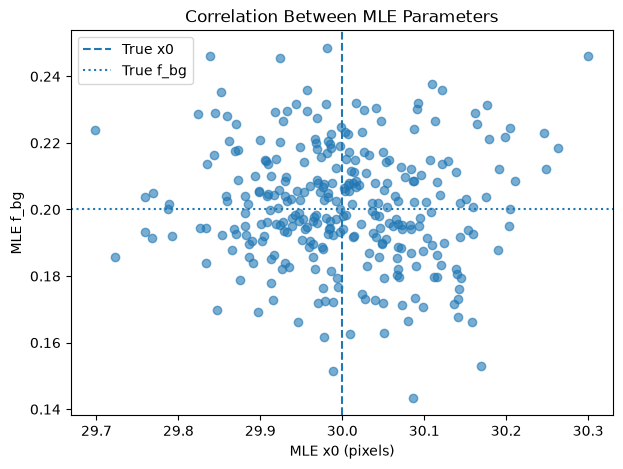

Correlation coefficient between x0 and f_bg: -0.0416


In [40]:
# Scatter plot of the two MLE parameters

plt.figure(figsize=(7, 5))
plt.scatter(mle_x0_results, mle_fbg_results, alpha=0.6)
plt.axvline(true_x0, linestyle="--", label="True x0")
plt.axhline(true_fbg, linestyle=":", label="True f_bg")
plt.xlabel("MLE x0 (pixels)")
plt.ylabel("MLE f_bg")
plt.title("Correlation Between MLE Parameters")
plt.legend()
plt.show()

parameter_correlation = np.corrcoef(mle_x0_results, mle_fbg_results)[0, 1]
print(f"Correlation coefficient between x0 and f_bg: {parameter_correlation:.4f}")


Absolutely no correlation present here with the x0 and f_bg, this is pure scatter.

BELOW:
The Cramér–Rao bound is a lower bound on the variance of an unbiased estimator under the assumed model. The comparison below is a diagnostic: the Monte Carlo variance should not be substantially smaller than the corresponding bound.

Empirical MLE x0 variance: 0.010354
CRB x0 variance:          0.010937
Empirical / CRB ratio:    0.9467


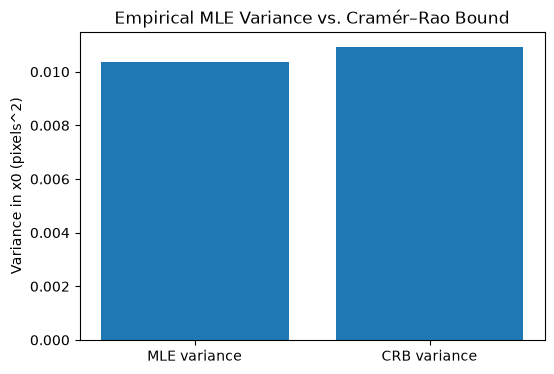

In [42]:
# Compare the empirical MLE x0 variance with the CRB reported earlier

mle_x0_variance = np.var(mle_x0_results, ddof=1)
print(f"Empirical MLE x0 variance: {mle_x0_variance:.6f}")
print(f"CRB x0 variance:          {sigma_x0_crb**2:.6f}")
print(f"Empirical / CRB ratio:    {mle_x0_variance / (sigma_x0_crb**2):.4f}")

plt.figure(figsize=(6, 4))
plt.bar(["MLE variance", "CRB variance"], [mle_x0_variance, sigma_x0_crb**2])
plt.ylabel("Variance in x0 (pixels^2)")
plt.title("Empirical MLE Variance vs. Cramér–Rao Bound")
plt.show()


Originally, I struggled greatly with this lab, but I figured out a way to make it extremely fun and interactive. I had ChatGPT run an entire check on the notebook and I got to really dig into how good ChatGPT is at what it does. I spent hours running these variance checks, plots tables that show error and it was so fun. I was actually extremely surprised that all of the variables returned incredibly small biases and variance over the course of hundreds of re-calculations. I had multiple plots and charts made to double check that the errors and the values I was seeing we're not garbage. It is absolutely incredible to me that these features are so easy to run and provide context to your data. My favorite part was running the Monte Carlo simulation 300 times and then plotting all of the tables and seeing how the randomly generated data was distributed and seeing how closely all of the random values were with each other graphically and according to what I needed them to be.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

I utilized ChatGPT for part three and part two in part two I specifically utilize ChatGPT to run the mixture model. I did not just have it run a random mixture model. I gave it the mixer model example from the lecture as well as the directions for the assignment. my goal was to create a mixture model that closely related the in class activities where I could compare and contrast methods. For part three I had ChatGPT run an entire brand new randomly generated data set through all of the same functions used in part two then completely run a validation check on everything. I kept prompting chat with extensive and difficult prompts to ensure that outputs from the model were accurate and strongly in correlation with the objectives of the lab. I was able to corroborate my findings as well as fix a couple of issues. I discovered chat made for example. It identified the error in the mean to be quite large so I investigated and eventually got ChatGPT to change how it thought about the error from devastating to understanding given the context of what our data meant.

When ChatGPT was utilized, it was utilized in a way such that copy pasting blindly did not happen without a reason. I also utilize ChatGPT to make tweaks to itself after running code and realizing it was not how I wanted I often had ChatGPT look back at the code had just written to optimize it or to account for missing variables or graphical additions that were not present in its original choice.

A specific example would be the mixture model where I could tell the end results were not aggressively wrong and I understood the general concept of the model from lecture and the code had provided however, each individual line I was not able to cross reference, but I knew that the end result and that the initial prompts were in line with what the goal of the question was. The ending checks are to be able to explain how I know the models above work.